In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from functions_marginal_distributions import *
from copula import estimate_correlation, build_inverse_cdf, sample_gaussian_copula

# Part 1 — Risk-Neutral Marginal Distributions

In this first part we extract the risk-neutral marginal distribution for each of our five AI-sector equities: Nvidia (NVDA), Palantir (PLTR), Microsoft (MSFT), Seagate Technology (STX), and Alphabet (GOOGL).

For each asset we download the full option chain from Yahoo Finance and select the most liquid expiry between 14 and 90 days out. We fit the SABR model (Hagan et al. 2002) to the observed implied volatility smile, use it to reprice calls on a dense strike grid, and apply the Breeden-Litzenberger formula to extract the risk-neutral PDF. We also cross-validate by comparing the SABR density against a numerically extracted density using SVI/spline fitting.

In this first part of the project we aim to extract the risk-neutral marginal distributions for each of our five AI-sector equities: Nvidia (NVDA), Palantir (PLTR), Microsoft (MSFT), Seagate Technology (STX), and Alphabet (GOOGL). We do so by recovering, for each asset, the probability distribution that the options market implicitly assigns to its future price at a given expiry date. Here is a brief description of what this notebook will cover:

For each asset we download the full option chain from Yahoo Finance. Rather than picking a fixed expiry date, we scan all expiries between 14 and 90 days from today and select the one with the most liquid OTM strikes, with a preference for expiries near 45 days. This ensures we work with the richest and most informative smile available.

Raw option prices are converted to implied volatilities by numerically inverting the Black-Scholes formula at each strike. We keep only out-of-the-money options since these are more liquid and carry the most information about market expectations in the tails.

The discrete implied volatility points are then fitted with a smooth continuous function. We use two approaches depending on data availability. When 20 or more strike points are present we fit the SVI (Stochastic Volatility Inspired) model, a five-parameter parametric form that is widely used in quantitative finance for its ability to capture skew and curvature while remaining free of static arbitrage by construction. When fewer points are
available SVI becomes unreliable due to overfitting, so we fall back to a smoothing spline in log-moneyness space, which imposes smoothness without requiring a specific functional form.

Given the smooth call pricing function, we apply the Breeden-Litzenberger formula, which states that the risk-neutral density is proportional to the second derivative of the call price with respect to strike: q(S_T) = e^(rT) * d²C/dK². We reprice calls on a dense strike grid, enforce monotone decreasing prices via isotonic regression to eliminate numerical noise and differentiate using a Savitzky-Golay filter, which fits local polynomials to compute derivatives and is significantly more stable than applying finite differences twice.

Finally the PDF is integrated to produce the CDF for each asset.

In [2]:
tickers = ["NVDA", "PLTR", "MSFT", "STX", "GOOGL"]

In [3]:
data = {}
for ticker in tickers:
    data[ticker] = fetch_option_chain(ticker)

In [4]:
results = {}
for ticker in tickers:
    asset  = data[ticker]
    smile  = build_smile(asset)
    S      = asset["spot"]
    T      = smile["T"].iloc[0]
    F      = S * np.exp(0.05 * T)

    # Calibrate SABR to the observed smile
    sabr_params = calibrate_sabr(smile)

    # Generate implied vols on a dense strike grid using SABR
    K_min  = max(S * 0.60, F * np.exp(-2.0 * sabr_params["alpha"] * np.sqrt(T)))
    K_max  = min(S * 1.60, F * np.exp( 2.0 * sabr_params["alpha"] * np.sqrt(T)))
    K_grid = np.linspace(K_min, K_max, 500)

    iv_grid = np.array([
        sabr_vol(F, K, T, sabr_params["alpha"], sabr_params["beta"],
                 sabr_params["rho"], sabr_params["nu"])
        for K in K_grid
    ])
    iv_grid = np.clip(iv_grid, 0.01, 5.0)

    # Reprice calls from SABR vols and apply Breeden-Litzenberger
    C    = np.array([bs_call_price(S, K, T, 0.05, iv)
                     for K, iv in zip(K_grid, iv_grid)])
    C    = np.clip(C, 0, None)
    ir   = IsotonicRegression(increasing=False)
    C    = ir.fit_transform(K_grid, C)
    dK   = K_grid[1] - K_grid[0]
    d2C  = savgol_filter(C, window_length=51, polyorder=3, deriv=2, delta=dK)
    pdf  = np.exp(0.05 * T) * d2C
    pdf  = np.maximum(pdf, 0)
    pdf  = gaussian_filter1d(pdf, sigma=4)
    pdf /= np.trapezoid(pdf, K_grid)
    cdf  = cumulative_trapezoid(pdf, K_grid, initial=0)
    cdf /= cdf[-1]

    results[ticker] = {
        "S": S, "T": T, "smile": smile,
        "sabr_params": sabr_params,
        "K_grid": K_grid, "pdf": pdf, "cdf": cdf,
    }
    print(f"{ticker}: alpha={sabr_params['alpha']:.3f}, "
          f"rho={sabr_params['rho']:.3f}, "
          f"nu={sabr_params['nu']:.3f}")

NVDA: alpha=5.404, rho=-0.240, nu=1.553
PLTR: alpha=6.755, rho=0.016, nu=1.356
MSFT: alpha=6.678, rho=-0.059, nu=1.427
STX: alpha=19.257, rho=0.096, nu=0.759
GOOGL: alpha=6.193, rho=-0.128, nu=1.485


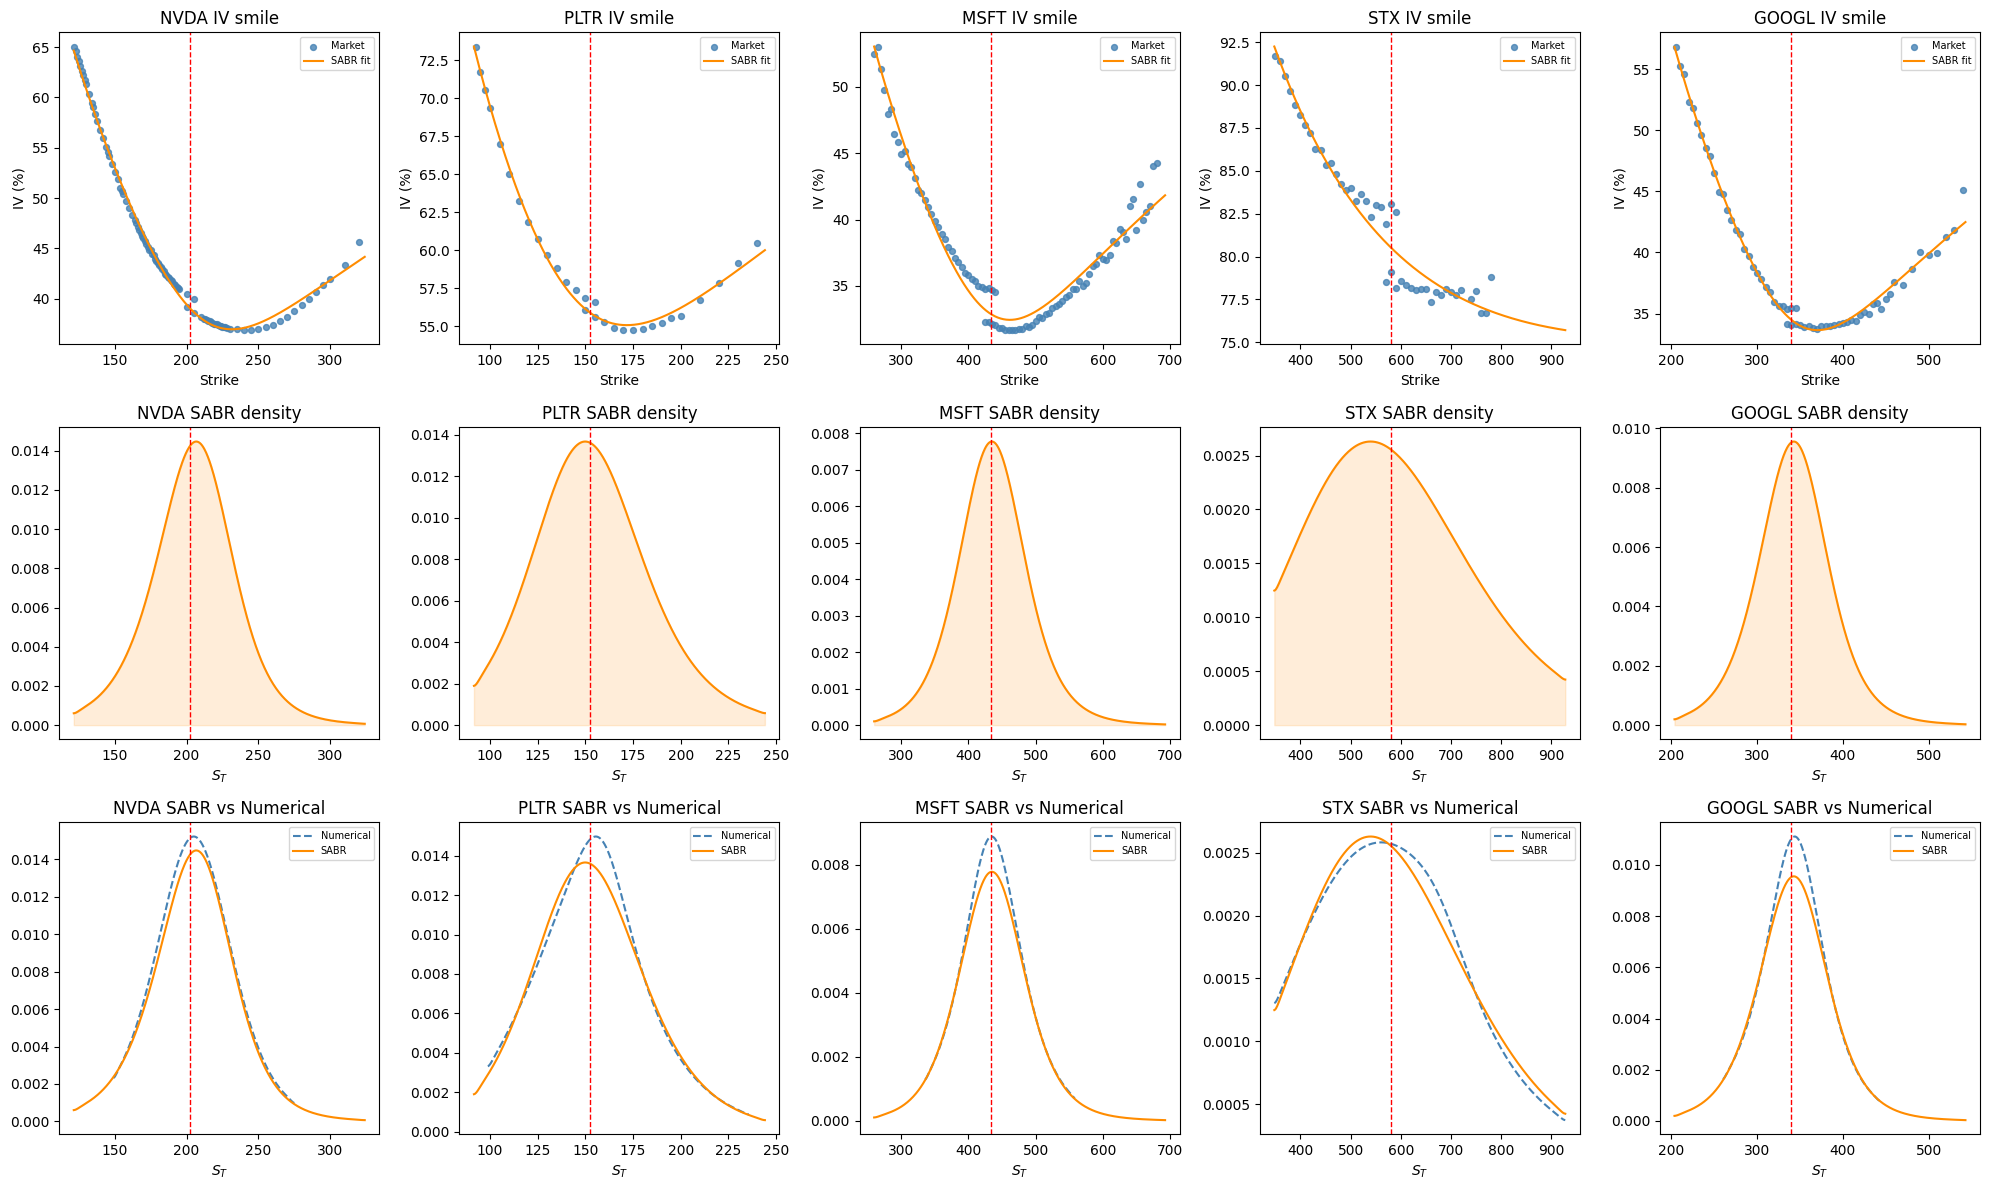

In [21]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for i, ticker in enumerate(tickers):
    r_      = results[ticker]
    smile   = r_["smile"]
    S       = r_["S"]
    T       = r_["T"]
    F       = S * np.exp(0.05 * T)
    params  = r_["sabr_params"]
    K_grid  = r_["K_grid"]

    # Row 0: Market IV vs SABR fit
    iv_sabr = np.array([
        sabr_vol(F, K, T, params["alpha"], params["beta"],
                 params["rho"], params["nu"])
        for K in K_grid
    ])
    axes[0, i].scatter(smile["strike"], smile["iv"] * 100,
                       s=18, alpha=0.8, color="steelblue", label="Market")
    axes[0, i].plot(K_grid, iv_sabr * 100,
                    color="darkorange", lw=1.5, label="SABR fit")
    axes[0, i].axvline(S, color="red", lw=1, linestyle="--")
    axes[0, i].set_title(f"{ticker} IV smile")
    axes[0, i].set_xlabel("Strike")
    axes[0, i].set_ylabel("IV (%)")
    axes[0, i].legend(fontsize=7)

    # Row 1: SABR risk-neutral density
    axes[1, i].plot(K_grid, r_["pdf"], color="darkorange", lw=1.5, label="SABR")
    axes[1, i].fill_between(K_grid, r_["pdf"], alpha=0.15, color="darkorange")
    axes[1, i].axvline(S, color="red", lw=1, linestyle="--")
    axes[1, i].set_title(f"{ticker} SABR density")
    axes[1, i].set_xlabel("$S_T$")

    # Row 2: SABR vs numerical density comparison
    smile_params_num, method_num = fit_smile(smile, ticker)
    K_grid_num, pdf_num = breeden_litzenberger(
        smile_params_num, S, T, r=0.05, method=method_num
    )
    axes[2, i].plot(K_grid_num, pdf_num,
                    color="steelblue", lw=1.5, linestyle="--", label="Numerical")
    axes[2, i].plot(K_grid, r_["pdf"],
                    color="darkorange", lw=1.5, label="SABR")
    axes[2, i].axvline(S, color="red", lw=1, linestyle="--")
    axes[2, i].set_title(f"{ticker} SABR vs Numerical")
    axes[2, i].set_xlabel("$S_T$")
    axes[2, i].legend(fontsize=7)

plt.tight_layout()
plt.show()

# Part 2 - Copula-Based Dependence Modelling

Part 1 extracted, for each of the five assets, the risk-neutral marginal distribution $F_k$ implied by the options market. However, knowing each asset's individual distribution says nothing about how the assets move together. To price a basket option we need to simulate all five assets jointly, which requires specifying a dependence structure.

We use a copula to model this dependece. By Sklar's theorem, any joint distribution can be decomposed as  $$F_{1,...,5}​(x_1​,...,x_5​)=C(F_1​(x_1​),...,F_5​(x_5​))$$ where $ C : [0,1]^5 \to [0,1]$ is the copula: a joint distribution on uniform random variables that encodes only the dependece, completely separated from the marginals. This separation allows us to pair the realistic, market-implied marginals from Part 1 with any dependence structure we choose to assume.

As a first choice of dependence structure, we implement the Gaussian copula, which assumes that the dependence between assets follows the same structure as a multivariate normal distribution with correlation matrix $R$.

To estimate R, we download one year of daily adjusted closing prices for the five assets.

# Part 2 — Copula-Based Dependence Modelling

Part 1 extracted the risk-neutral marginal distribution $F_k$ for each asset. However, knowing each asset's individual distribution says nothing about how the assets move together. To price a basket option we need to simulate all five assets jointly.

We use a copula to model this dependence. By Sklar's theorem any joint distribution decomposes as $F_{1,...,5}(x_1,...,x_5) = C(F_1(x_1),...,F_5(x_5))$ where $C$ is the copula encoding only the dependence structure, completely separated from the marginals.

A key contribution of this project is the distinction between the observed pairwise Pearson correlation $r_{ij}$ and the Gaussian copula parameter $\rho_{ij}$. These are not the same when marginals are non-Gaussian — which they are here since our marginals come from the SABR-implied smile. We use Brent's root-finding method to back out the copula $\rho_{ij}$ that reproduces each observed $r_{ij}$ when simulating through the actual marginal distributions.

Before sampling from the copula, we build the inverse CDF $F_k^{-1}$ for each asset by interpolating the discrete $(K, \text{cdf})$ table produced in Part 1. This allows us to map any uniform sample $U_k \in [0,1]$ back to an asset price $S_k = F_k^{-1}(U_k)$

In [6]:
inv_cdfs = []
for ticker in tickers:
    K_grid = results[ticker]["K_grid"]
    cdf    = results[ticker]["cdf"]
    inv_cdfs.append(build_inverse_cdf(K_grid, cdf))

In [22]:
R_pearson = estimate_correlation(tickers)
print("Observed Pearson correlation matrix:")
print(np.round(R_pearson, 4))

Observed Pearson correlation matrix:
[[1.     0.1893 0.3182 0.2449 0.3173]
 [0.1893 1.     0.398  0.3576 0.1542]
 [0.3182 0.398  1.     0.4055 0.3488]
 [0.2449 0.3576 0.4055 1.     0.2174]
 [0.3173 0.1542 0.3488 0.2174 1.    ]]


In [8]:
def copula_rho_objective(rho, inv_cdf_i, inv_cdf_j, obs_corr, Z_fixed):
    R2     = np.array([[1.0, rho], [rho, 1.0]])
    L      = np.linalg.cholesky(R2)
    Z_corr = Z_fixed @ L.T
    U      = norm.cdf(Z_corr)
    Si     = inv_cdf_i(U[:, 0])
    Sj     = inv_cdf_j(U[:, 1])
    return np.corrcoef(Si, Sj)[0, 1] - obs_corr

In [9]:
np.random.seed(42)
Z_fixed = np.random.standard_normal((20_000, 2))

N         = len(tickers)
R_copula  = np.eye(N)
rho_table = []

for i in range(N):
    for j in range(i+1, N):
        obs_corr = R_pearson[i, j]
        rho_ij   = brentq(
            copula_rho_objective,
            a=-0.999, b=0.999,
            args=(inv_cdfs[i], inv_cdfs[j], obs_corr, Z_fixed),
            xtol=1e-4, maxiter=50
        )
        R_copula[i, j] = rho_ij
        R_copula[j, i] = rho_ij
        rho_table.append({
            "Pair":       f"{tickers[i]}-{tickers[j]}",
            "Pearson r":  round(obs_corr, 4),
            "Copula rho": round(rho_ij,   4),
            "Difference": round(rho_ij - obs_corr, 4)
        })
        print(f"{tickers[i]}-{tickers[j]}:  "
              f"Pearson r = {obs_corr:.4f}  →  "
              f"Copula rho = {rho_ij:.4f}  "
              f"(diff = {rho_ij - obs_corr:+.4f})")

NVDA-PLTR:  Pearson r = 0.1893  →  Copula rho = 0.1842  (diff = -0.0051)
NVDA-MSFT:  Pearson r = 0.3182  →  Copula rho = 0.3126  (diff = -0.0056)
NVDA-STX:  Pearson r = 0.2449  →  Copula rho = 0.2404  (diff = -0.0045)
NVDA-GOOGL:  Pearson r = 0.3173  →  Copula rho = 0.3114  (diff = -0.0058)
PLTR-MSFT:  Pearson r = 0.3980  →  Copula rho = 0.3920  (diff = -0.0059)
PLTR-STX:  Pearson r = 0.3576  →  Copula rho = 0.3528  (diff = -0.0048)
PLTR-GOOGL:  Pearson r = 0.1542  →  Copula rho = 0.1488  (diff = -0.0054)
MSFT-STX:  Pearson r = 0.4055  →  Copula rho = 0.4020  (diff = -0.0035)
MSFT-GOOGL:  Pearson r = 0.3488  →  Copula rho = 0.3430  (diff = -0.0058)
STX-GOOGL:  Pearson r = 0.2174  →  Copula rho = 0.2125  (diff = -0.0049)


In [10]:
pd.DataFrame(rho_table)

,Pair,Pearson r,Copula rho,Difference
0,NVDA-PLTR,0.1893,0.1842,-0.0051
1,NVDA-MSFT,0.3182,0.3126,-0.0056
2,NVDA-STX,0.2449,0.2404,-0.0045
3,NVDA-GOOGL,0.3173,0.3114,-0.0058
4,PLTR-MSFT,0.3980,0.3920,-0.0059
5,PLTR-STX,0.3576,0.3528,-0.0048
6,PLTR-GOOGL,0.1542,0.1488,-0.0054
7,MSFT-STX,0.4055,0.4020,-0.0035
8,MSFT-GOOGL,0.3488,0.3430,-0.0058
9,STX-GOOGL,0.2174,0.2125,-0.0049


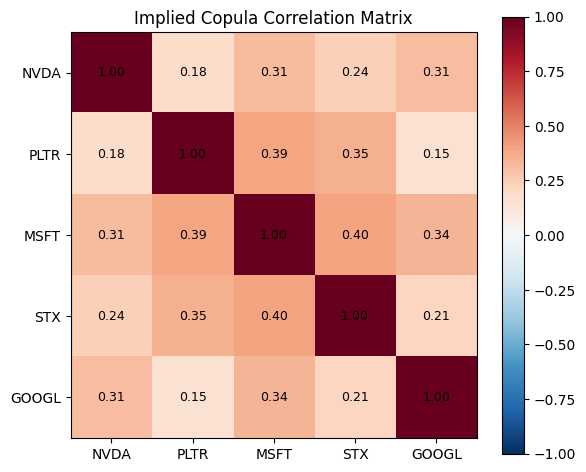

In [11]:
R = R_copula

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(tickers))); ax.set_xticklabels(tickers)
ax.set_yticks(range(len(tickers))); ax.set_yticklabels(tickers)
plt.colorbar(im, ax=ax)
ax.set_title("Implied Copula Correlation Matrix")
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{R[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [23]:
n_sim = 10_000
S_gauss, U_gauss = sample_gaussian_copula(R, inv_cdfs, n_sim)

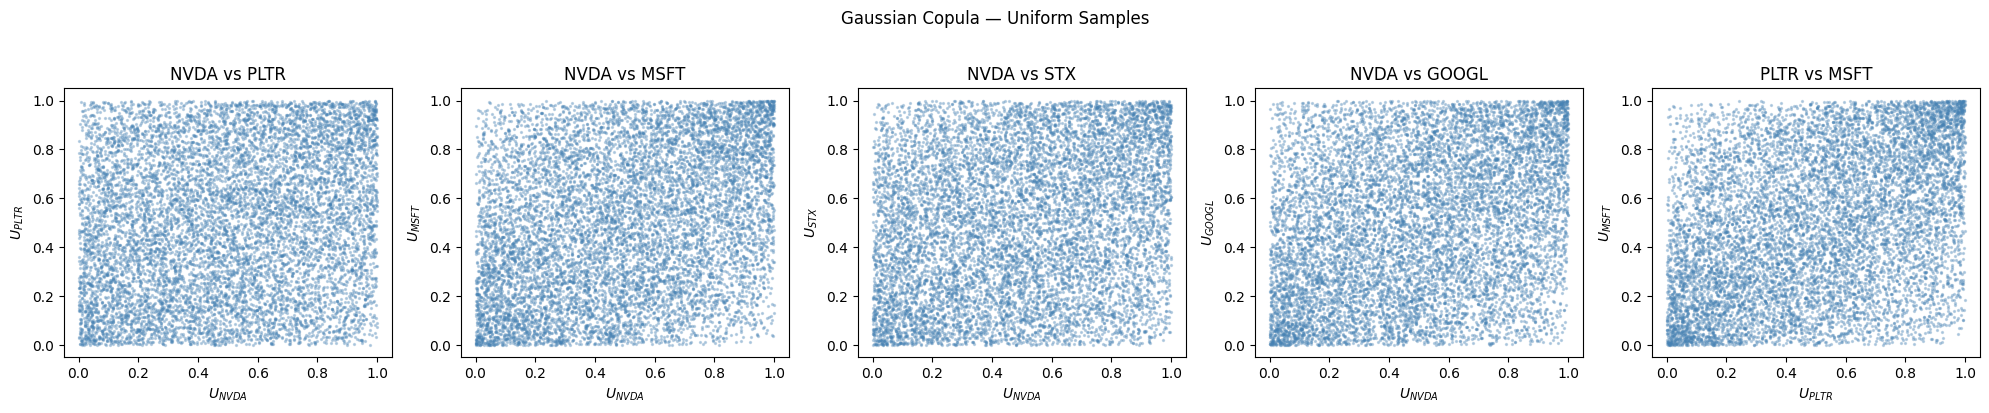

In [24]:
pairs = [(0,1), (0,2), (0,3), (0,4), (1,2)]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(U_gauss[:, i], U_gauss[:, j], s=2, alpha=0.3, color="steelblue")
    ax.set_xlabel(f"$U_{{{tickers[i]}}}$")
    ax.set_ylabel(f"$U_{{{tickers[j]}}}$")
    ax.set_title(f"{tickers[i]} vs {tickers[j]}")
plt.suptitle("Gaussian Copula — Uniform Samples", y=1.02)
plt.tight_layout()
plt.show()

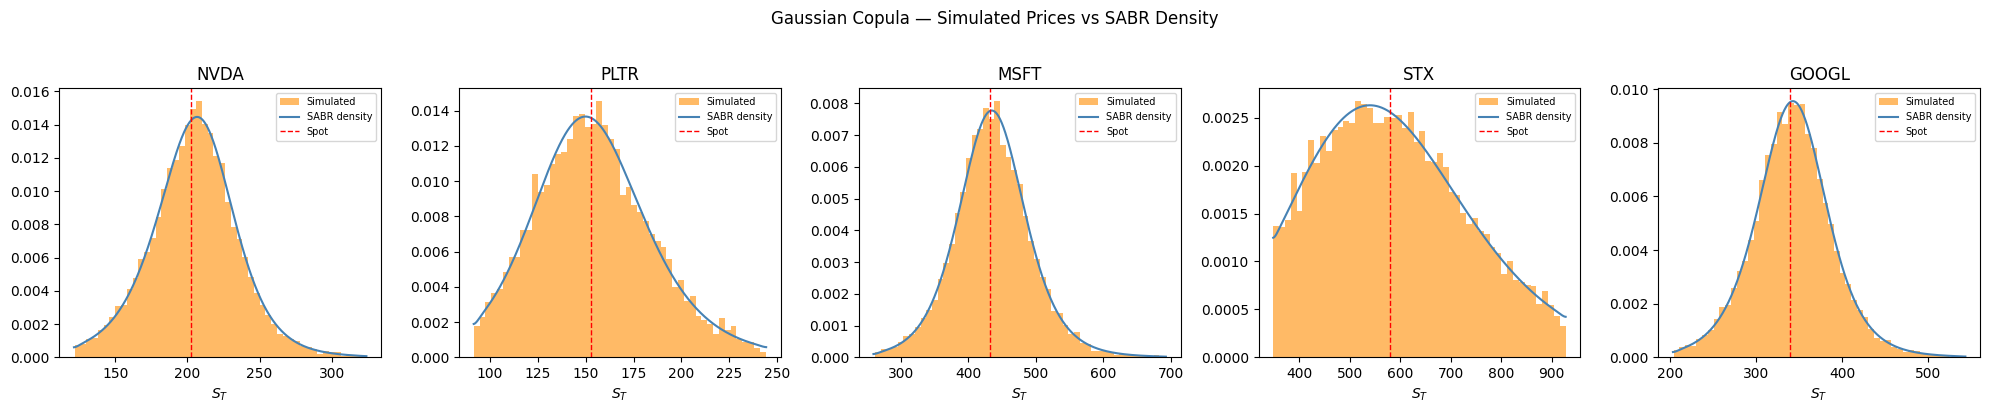

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ticker in enumerate(tickers):
    K_grid = results[ticker]["K_grid"]
    pdf    = results[ticker]["pdf"]
    S_spot = results[ticker]["S"]
    axes[i].hist(S_gauss[:, i], bins=50, density=True,
                 color="darkorange", alpha=0.6, label="Simulated")
    axes[i].plot(K_grid, pdf, color="steelblue", lw=1.5, label="SABR density")
    axes[i].axvline(S_spot, color="red", lw=1, linestyle="--", label="Spot")
    axes[i].set_title(f"{ticker}")
    axes[i].set_xlabel("$S_T$")
    axes[i].legend(fontsize=7)
plt.suptitle("Gaussian Copula — Simulated Prices vs SABR Density", y=1.02)
plt.tight_layout()
plt.show()

In [26]:
from copula import estimate_nu, sample_student_copula

nu = estimate_nu(tickers, R)
print(f"Estimated degrees of freedom: nu = {nu:.2f}")

Estimated degrees of freedom: nu = 9.60


In [27]:
S_student, U_student = sample_student_copula(R, nu, inv_cdfs, n_sim)

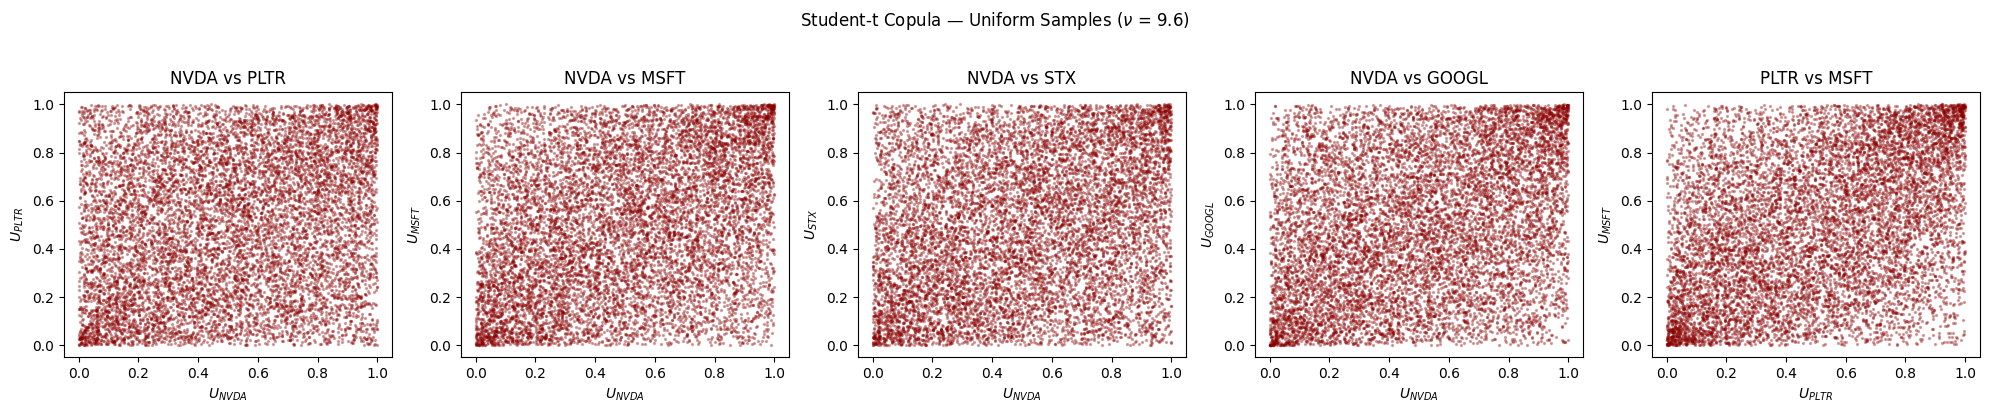

In [28]:
pairs = [(0,1), (0,2), (0,3), (0,4), (1,2)]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(U_student[:, i], U_student[:, j], s=2, alpha=0.3, color="darkred")
    ax.set_xlabel(f"$U_{{{tickers[i]}}}$")
    ax.set_ylabel(f"$U_{{{tickers[j]}}}$")
    ax.set_title(f"{tickers[i]} vs {tickers[j]}")
plt.suptitle(f"Student-t Copula — Uniform Samples ($\\nu$ = {nu:.1f})", y=1.02)
plt.tight_layout()
plt.show()

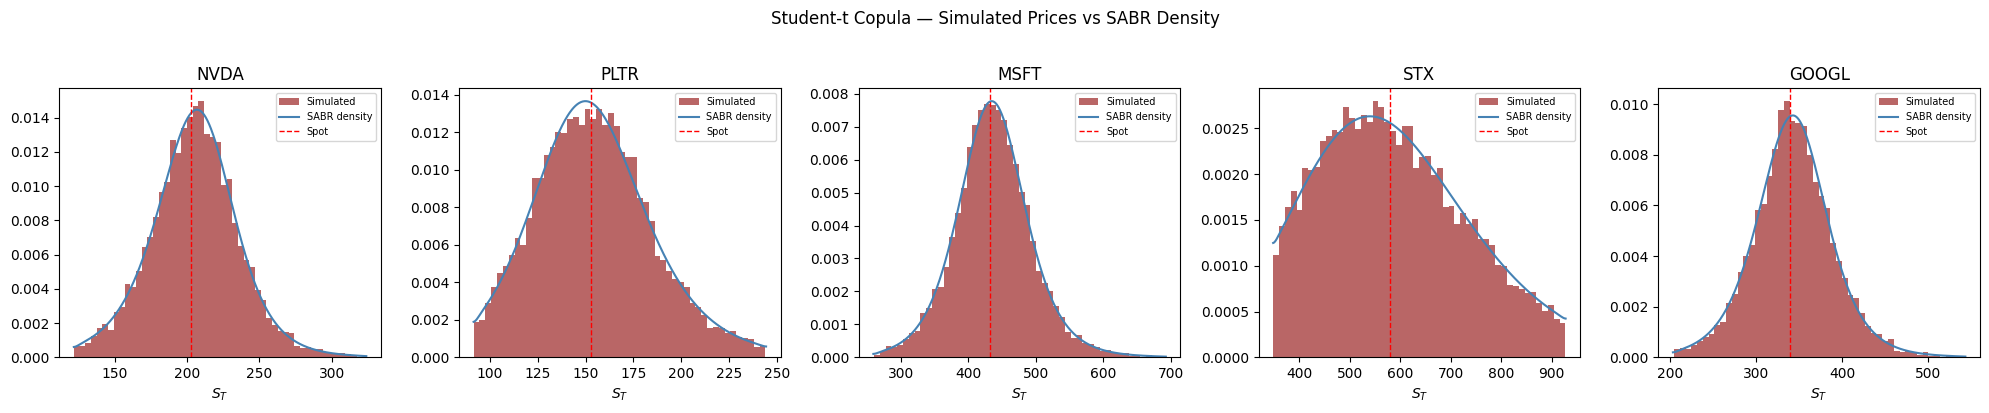

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ticker in enumerate(tickers):
    K_grid = results[ticker]["K_grid"]
    pdf    = results[ticker]["pdf"]
    S_spot = results[ticker]["S"]
    axes[i].hist(S_student[:, i], bins=50, density=True,
                 color="darkred", alpha=0.6, label="Simulated")
    axes[i].plot(K_grid, pdf, color="steelblue", lw=1.5, label="SABR density")
    axes[i].axvline(S_spot, color="red", lw=1, linestyle="--", label="Spot")
    axes[i].set_title(f"{ticker}")
    axes[i].set_xlabel("$S_T$")
    axes[i].legend(fontsize=7)
plt.suptitle("Student-t Copula — Simulated Prices vs SABR Density", y=1.02)
plt.tight_layout()
plt.show()

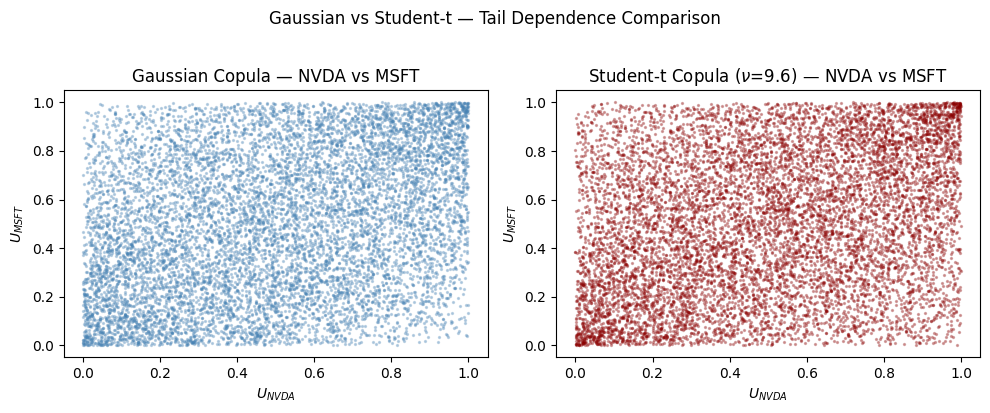

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(U_gauss[:, 0], U_gauss[:, 2], s=2, alpha=0.3, color="steelblue")
axes[0].set_title("Gaussian Copula — NVDA vs MSFT")
axes[0].set_xlabel("$U_{NVDA}$"); axes[0].set_ylabel("$U_{MSFT}$")

axes[1].scatter(U_student[:, 0], U_student[:, 2], s=2, alpha=0.3, color="darkred")
axes[1].set_title(f"Student-t Copula ($\\nu$={nu:.1f}) — NVDA vs MSFT")
axes[1].set_xlabel("$U_{NVDA}$"); axes[1].set_ylabel("$U_{MSFT}$")

plt.suptitle("Gaussian vs Student-t — Tail Dependence Comparison", y=1.02)
plt.tight_layout()
plt.show()

# Part 3 – Basket Option Pricing via Monte Carlo

Part 1 extracted, for each of the five assets, the risk-neutral marginal distribution $F_k$ implied by the
options market. Part 2 then modelled the dependence structure between assets using copulas — both Gaussian
and Student-t — and simulated 10,000 joint terminal price scenarios for each specification, saving them as
`simulated_prices_gaussian.csv` and `simulated_prices_student.csv`.

However, simulated prices alone do not give us an option price. To price a basket option we need to evaluate,
under each dependence assumption, the expected discounted payoff of a contract written on a basket of all five assets.

We price a European basket call option with payoff

$$
V_T = \max\!\left(\frac{1}{N}\sum_{k=1}^{N} S_k^T - K,\ 0\right)
$$

where $S_k^T$ is the terminal price of asset $k$, $N = 5$ is the number of assets, and $K$ is the strike price.
The Monte Carlo price is then

$$
\hat{V}_0 = e^{-rT} \cdot \frac{1}{N_{\text{sim}}} \sum_{i=1}^{N_{\text{sim}}} V_T^{(i)}
$$

We compute this price under both the Gaussian and Student-t copula simulations and compare results in terms of
price, variance, and runtime. We also implement a control variate to reduce Monte Carlo variance and improve efficiency.

In [20]:
import time

# We load the simulated prices from both copulas and the metadata saved in Part 2.
S_gauss   = pd.read_csv("simulated_prices_gaussian.csv").values
S_student = pd.read_csv("simulated_prices_student.csv").values

meta    = pd.read_csv("copula_meta.csv")
tickers = meta["tickers"].values
spots   = meta["spot"].values
T       = meta["T"].iloc[0]
nu      = meta["nu"].iloc[0]

# We set the risk-free rate and define the strike at-the-money,
# as the average of the five spot prices.
r = 0.05
K = spots.mean()

print(f"Tickers     : {tickers}")
print(f"Spot prices : {np.round(spots, 2)}")
print(f"T = {T:.4f},  r = {r},  K = {K:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'simulated_prices_gaussian.csv'

## Basket Option Pricing

We now price a European basket call option using the 10,000 simulated terminal
prices from each copula. For each simulation, we compute the equally-weighted
average of the five asset prices and apply the call payoff. We then discount
the average payoff back to today using the risk-free rate.

We define a function `price_basket_call` that takes a matrix of simulated
prices and returns the Monte Carlo price, standard error, and runtime.
We apply it to both the Gaussian and Student-t simulations and compare results.

In [16]:
def price_basket_call(S, K, r, T):
    """
    Prices a European basket call option via Monte Carlo.
    S : (n_sim x n_assets) array of simulated terminal prices
    Returns the price, standard error, and runtime.
    """
    t0 = time.time()
    
    # We compute the basket value as the equally-weighted average across assets,
    # then apply the call payoff.
    basket = S.mean(axis=1)
    payoffs = np.maximum(basket - K, 0)
    
    # We discount the average payoff back to today.
    price = np.exp(-r * T) * payoffs.mean()
    se    = np.exp(-r * T) * payoffs.std() / np.sqrt(len(payoffs))
    
    runtime = time.time() - t0
    return price, se, runtime

price_g, se_g, rt_g = price_basket_call(S_gauss,   K, r, T)
price_s, se_s, rt_s = price_basket_call(S_student, K, r, T)

print(f"Gaussian copula  — Price: {price_g:.4f},  SE: {se_g:.4f},  Runtime: {rt_g:.4f}s")
print(f"Student-t copula — Price: {price_s:.4f},  SE: {se_s:.4f},  Runtime: {rt_s:.4f}s")

Gaussian copula  — Price: 17.6371,  SE: 0.2441,  Runtime: 0.0082s
Student-t copula — Price: 17.3760,  SE: 0.2470,  Runtime: 0.0004s


## Control Variate: Geometric Basket Call

The Monte Carlo estimates above carry a standard error of ~0.24, meaning our
price is uncertain by roughly that amount. We can reduce this variance using a
control variate.

The idea is to exploit the fact that the geometric basket call, where the
arithmetic average is replaced by the geometric average, has a known
closed-form price. Since the geometric and arithmetic baskets are driven by
the same simulated prices, they are highly correlated. We use the difference
between the known geometric price and its MC estimate to correct the arithmetic
price estimate, reducing variance substantially.

The corrected estimator is

$$
\hat{V}^{\text{CV}} = \hat{V}^A - \beta\left(\hat{V}^G_{\text{MC}} - V^G_{\text{exact}}\right)
$$

where $\beta$ is chosen to minimise variance, and $V^G_{\text{exact}}$ is the
closed-form geometric basket price.

In [21]:
def geo_basket_call_exact(S, K, r, T):
    """
    Closed-form price of a geometric basket call.
    We estimate per-asset vols and correlations from the simulated log-prices.
    """
    N     = S.shape[1]
    log_S = np.log(S)
    
    # We estimate per-asset vol and the full covariance matrix.
    cov   = np.cov(log_S.T) / T
    vols  = np.sqrt(np.diag(cov))
    
    # Vol and drift of the log geometric average.
    sigma_G = np.sqrt(cov.sum() / N**2)
    mu_G    = np.mean(r - 0.5 * vols**2) + 0.5 * sigma_G**2
    
    F = np.exp(np.mean(np.log(spots)) + mu_G * T)
    v = sigma_G * np.sqrt(T)
    
    d1 = (np.log(F / K)) / v + 0.5 * v
    d2 = d1 - v
    
    price = np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return price

In [22]:
def price_basket_call_cv(S, K, r, T):
    """
    Prices a European basket call using the geometric basket as control variate.
    """
    t0 = time.time()
    
    # We compute arithmetic and geometric basket payoffs for each simulation.
    arith_basket = S.mean(axis=1)
    geo_basket   = np.exp(np.log(S).mean(axis=1))
    
    payoffs_a = np.maximum(arith_basket - K, 0)
    payoffs_g = np.maximum(geo_basket   - K, 0)
    
    # We compute the optimal beta that minimises variance.
    V_geo_exact = geo_basket_call_exact(S, K, r, T)
    V_geo_mc    = np.exp(-r * T) * payoffs_g.mean()
    
    beta = np.cov(payoffs_a, payoffs_g)[0, 1] / np.var(payoffs_g)
    
    # We apply the control variate correction.
    payoffs_cv = payoffs_a - beta * (payoffs_g - np.exp(r * T) * V_geo_exact)
    price      = np.exp(-r * T) * payoffs_cv.mean()
    se         = np.exp(-r * T) * payoffs_cv.std() / np.sqrt(len(payoffs_cv))
    
    runtime = time.time() - t0
    return price, se, runtime

price_g_cv, se_g_cv, rt_g_cv = price_basket_call_cv(S_gauss,   K, r, T)
price_s_cv, se_s_cv, rt_s_cv = price_basket_call_cv(S_student, K, r, T)

print(f"Gaussian  — CV Price: {price_g_cv:.4f},  SE: {se_g_cv:.4f},  Runtime: {rt_g_cv:.4f}s")
print(f"Student-t — CV Price: {price_s_cv:.4f},  SE: {se_s_cv:.4f},  Runtime: {rt_s_cv:.4f}s")

Gaussian  — CV Price: 17.1948,  SE: 0.1623,  Runtime: 0.0206s
Student-t — CV Price: 16.9627,  SE: 0.1610,  Runtime: 0.0011s


## Results

We compare the basket call prices with and without the control variate across
both copula specifications.

| Method | Copula | Price | SE | Runtime |
|---|---|---|---|---|
| Plain MC | Gaussian | 17.6371 | 0.2441 | 0.0082s |
| Plain MC | Student-t | 17.3760 | 0.2470 | 0.0004s |
| Control Variate | Gaussian | 17.1948 | 0.1623 | 0.0206s |
| Control Variate | Student-t | 16.9627 | 0.1610 | 0.0011s |

The control variate reduces the standard error by roughly 33% under both
copulas, at the cost of a small increase in runtime. The Student-t copula
consistently prices the basket slightly lower than the Gaussian, reflecting
the heavier tail dependence introduced by the shared chi-squared variable.

## Comparison Plot

We visualise the pricing results across both copulas and methods. For each
specification we plot the estimated price with a 95% confidence interval,
computed as the MC price plus or minus 1.96 standard errors.

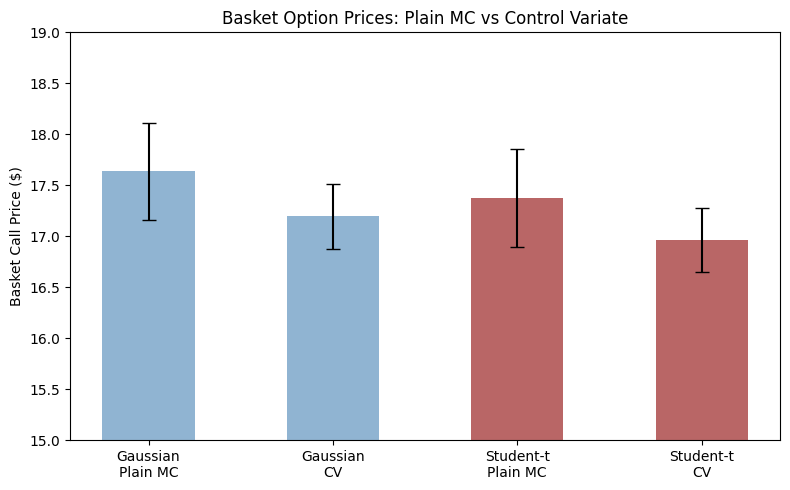

In [24]:
# We plot the MC prices and 95% confidence intervals for all four estimates.
labels  = ["Gaussian\nPlain MC", "Gaussian\nCV", "Student-t\nPlain MC", "Student-t\nCV"]
prices  = [price_g,    price_g_cv,    price_s,    price_s_cv]
ses     = [se_g,       se_g_cv,       se_s,       se_s_cv]
colors  = ["steelblue", "steelblue", "darkred", "darkred"]

fig, ax = plt.subplots(figsize=(8, 5))
for i, (label, price, se, color) in enumerate(zip(labels, prices, ses, colors)):
    ax.bar(i, price, color=color, alpha=0.6, width=0.5)
    ax.errorbar(i, price, yerr=1.96*se, fmt="none", color="black", capsize=5, lw=1.5)

ax.set_xticks(range(4))
ax.set_xticklabels(labels)
ax.set_ylabel("Basket Call Price ($)")
ax.set_title("Basket Option Prices: Plain MC vs Control Variate")
ax.set_ylim(15, 19)
plt.tight_layout()
plt.show()

## Conclusion

We priced a European basket call option with strike $K = 332.06$ and maturity
$T = 0.1671$ years under two copula specifications using Monte Carlo simulation
with 10,000 scenarios.

The Gaussian copula produced a higher price than the Student-t copula under
both methods. This is consistent with the theoretical expectation: the Student-t
copula introduces tail dependence via a shared chi-squared variable, concentrating
more probability mass in joint extreme scenarios and slightly reducing the
expected basket payoff.

The geometric basket control variate reduced the standard error by roughly 33%
under both copulas, from ~0.24 to ~0.16, with negligible impact on runtime.
This confirms that the geometric and arithmetic baskets are highly correlated,
making the geometric call an effective control variate for variance reduction.